# Análise de Dados de um Inversor Trifásico para Acionamentos Elétricos

<h2 id="sumario" style="color: blue;">Sumário</h2>

<ul>
    <li><h3><a href="#ref" style="color: blue;">Referências</a></h3></li>
    <li><h3><a href="#intro" style="color: blue;">Introdução</a></h3>
        <ul>
            <li><h5><a href="#context" style="color: black;">Contextualização</a></h5></li>
            <li><h5><a href="#dataset" style="color: black;">Informações do Dataset</a></h5></li>
            <li><h5><a href="#obj" style="color: black;">Objetivo Geral</a></h5></li>
        </ul>
    </li>
    <li><h3><a href="#bib" style="color: blue;">Bibliotecas</a></h3></li>
        <ul>
            <li><h5><a href="#func_aux" style="color: black;"> Configurações dos plots e Funções Auxiliares</a></h5></li>
        </ul>
    <li><h3><a href="#Leit_ini" style="color: blue;">Leitura, Tratamento e Interpretação Inicial dos Dados</a></h3></li>
        <ul>
            <li><h5><a href="#leit" style="color: black;"> Leitura</a></h5></li>
            <li><h5><a href="#trat_brut" style="color: black;"> Tratamento Bruto</a></h5></li>
            <li><h5><a href="#descr_ini" style="color: black;"> Descrição Inicial dos Dados</a></h5></li>
            <li><h5><a href="#prob" style="color: black;"> Análise Inicial do Problema</a></h5></li>
        </ul>
    <li><h3><a href="#estat" style="color: blue;">Estatística Descritiva</a></h3></li>
     <ul>
        <li><h5><a href="#ana_ini" style="color: black;"> Análise e Interpretação Inicial</a></h5></li>
         <li><h5><a href="#comp_dad" style="color: black;"> Comprovação com os Dados Fornecidos</a></h5></li>
        <li><h5><a href="#idi_ses" style="color: black;"> Identificando e Separando Sessões</a></h5></li>
        <li><h5><a href="#corr_alt" style="color: black;"> Análise de dois sinais com correlação de Pearson alta</a></h5></li>
        <li><h5><a href="#corr" style="color: black;"> Correlação entre as Variáveis</a></h5></li>
        <li><h5><a href="#paradox" style="color: black;"> Análise das Matrizes de Correlação e o Paradoxo de Simpson</a></h5></li>
        <li><h5><a href="#esp" style="color: black;"> Relações espúrias</a></h5></li>
     </ul>
</ul>

## <a id="ref"></a>Referências

**Referência do Artigo**:
M. Stender, O. Wallscheid and J. Böcker, "Data Set Description: Three-Phase IGBT Two-Level Inverter for Electrical Drives," Paderborn University, Germany, 2020.

**Referência do Dataset**: M. Stender, O. Wallscheid and J. Böcker, "Three-phase IGBT two-level inverter for electrical drives (data)," Kaggle, 2020. Disponível em: https://www.kaggle.com/stender/inverter-data-set.


## Identificações para o Trabalho

### Integrantes
#### <a style = "color:blue">Cleyton Geraldo Paula Maciel,</a> 
#### <a style = "color:yellow"> Danilo Naime Valles Moreira,</a> 
#### <a style = "color:green">Thales da Cunha Tobias,</a>

## Introdução <a id = "intro"></a> 

### <a id="context"></a> Contextualização (<a style = "color:blue">Cleyton,</a><a style = "color:yellow"> Danilo</a> e <a style = "color:green">Thales</a>)

  Motores de indução trifásicos são os responsáveis majoritários pela força motriz industrial. Sendo assim, técnicas de acionamento e controle são essenciais e extremamente relevantes para contornar a dificuldade de manejar seu comportamento, por exempo, de variáveis como velocidade, torque, resposta transitória e estabilidade a variações de carga.
  
  Dentre as técnicas de acionamentos, o Controle de Campo Vetorial (Field-Oriented Control) é empregado para modelar motores de indução visando separar as componentes responsáveis por gerar torque e excitar o campo magnético da máquina, com o objetivo de facilitar a obtenção das respostas desejadas de operação.

  A técnica consiste em construir uma malha fechada em que as variáveis de controle (sinal que será usado para modular o chaveameto do inversor) do método FOC são as tensões de saída do inversor que alimenta o motor de indução. Como mostrado na **[Figura 1](#malha_controle)**
  

<figure id="malha_controle" style="text-align: center;">
    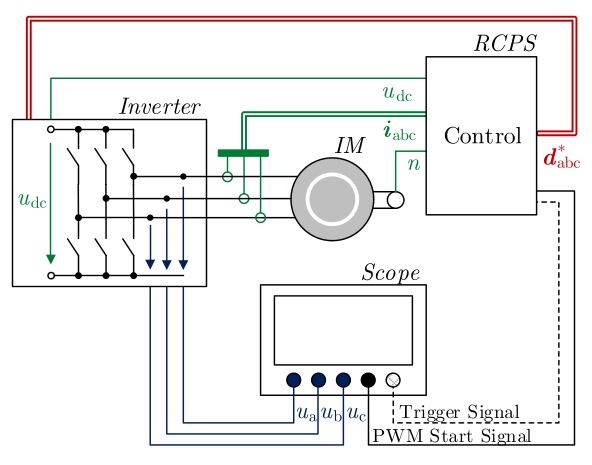
    <figcaption>
        <b>Figura 1:</b> Esquema da Malha de Controle (Retirado de STENDER et al., 2020).
    </figcaption>
</figure>

Entretanto, os sensores para medir as tensões de saída do inversor são caros e consequentemente é optado por desenvolver modelos que estimem essa variável, com o intuito de viabilizar economicamente o projeto. Sendo assim o objetivo desse trabalho é desenvolver um modelo para estimar as leituras reais através de outros sensores disponíveis, visando a diminuição do custo total sem perda expressiva do controle desejado. 




### <a id = "dataset"></a> Informações do Dataset

#### <a style = "color:blue">Cleyton,</a><a style = "color:yellow"> Danilo</a> e <a style = "color:green">Thales</a>

O dataset foi disponibilizado pelo dapartamento **LEA (Power Electronics and Electrical Drives)** da **Universidade Paderborn na Alemanha** com o intuito de proporcionar os dados necessários para a contrução do modelo para fins acadêmicos e de pesquisas. Juntamente, um artigo de descrição do processo de aquisição, estruturação e contextualização é fornecido com as informações necessárias.
**Os direitos sobre os dados são reservados aos autores mas disponíveis para estudos e utilização desde que sejam devidamente referenciados**.

### <a id = "obj"></a> Objetivo Geral
#### <a style = "color:blue">Cleyton,</a><a style = "color:yellow"> Danilo</a> e <a style = "color:green">Thales</a>

O objetivo é dividido em duas etapas:

* Obter um **modelo para as tensões médias de saída do inversor** que serão utilizadas como variáveis de controle para o método de controle vetorial
* Achar os **ciclos de trabalho que fornecem as tensões médias** que irão realizar o controle.


>### <span style="color:red"> OBS: Esse trabalho visa desenvolver o primeiro modelo, ou seja, cumprir o primeiro objetivo</span>

<a id = "bib"></a>
## Bibliotecas
**Descrição das Bibliotecas Especifícas**
* **Seaborn** : Análise Estatística
* **Statsmodels** : Análise Estatística


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statistics as st
from sklearn.preprocessing import StandardScaler

<a id ="func_aux"></a>
### Configurações dos plots e Funções Auxiliares

In [3]:
#Configurações
fig_s = (13,4)
ax_s = 12
tick_s = 10
title_s = 14

#Padronização dos Gráficos
def plot_config(titulo, x, y):
    plt.figure(figsize = (fig_s))
    plt.title(f'{titulo}', fontsize = title_s)
    plt.xlabel(f'{x}', fontsize = ax_s)
    plt.ylabel(f'{y}', fontsize = ax_s)

## Leitura, Tratamento e Interpretação Inicial dos Dados

### <a id = "leit"></a>Leitura

In [4]:
df = pd.read_csv("/home/cgpm/Documentos/Datasets/inversor/archive/Inverter Data Set.csv")

In [5]:
df.head()

,n_k,u_dc_k,u_dc_k-1,u_dc_k-2,u_dc_k-3,i_a_k,i_b_k,i_c_k,i_a_k-1,i_b_k-1,...,i_c_k-3,d_a_k-2,d_b_k-2,d_c_k-2,d_a_k-3,d_b_k-3,d_c_k-3,u_a_k-1,u_b_k-1,u_c_k-1
0,3001.406296,567.985297,567.689956,567.431534,567.948379,2.461991,-1.792057,-0.716639,2.729208,-2.098439,...,-0.613965,0.667181,0.874633,0.125367,0.706206,0.862754,0.137246,360.541201,510.640963,82.471117
1,3001.468250,567.911462,567.985297,567.689956,567.431534,2.292110,-1.556948,-0.757338,2.461991,-1.792057,...,-0.758263,0.642184,0.880046,0.119954,0.667181,0.874633,0.125367,346.410081,513.190083,79.729357
2,3001.527815,567.911462,567.911462,567.985297,567.689956,2.155288,-1.332946,-0.840587,2.292110,-1.556948,...,-0.698139,0.611911,0.884307,0.115693,0.642184,0.880046,0.119954,329.440240,515.804643,77.924637
3,3001.585080,567.653039,567.911462,567.911462,567.985297,2.048768,-1.135788,-0.925686,2.155288,-1.332946,...,-0.716639,0.578149,0.888915,0.111085,0.611911,0.884307,0.115693,311.058880,517.537603,75.478717
4,3001.640131,567.579204,567.653039,567.911462,567.911462,1.952350,-0.918266,-1.027434,2.048768,-1.135788,...,-0.757338,0.541979,0.892123,0.107877,0.578149,0.888915,0.111085,290.481760,519.138403,73.580077



### <a id = "trat_brut"></a> Tratamento Bruto

Através das funções **.isna** (Verifica Not a Number (booleano)) e **isnull** (Verifica valores nulos (booleano)) embutidas em **.describe()**, obtemos a contagem dessas proposições. 

$$\sum(\text{Trues}) = \sum(\text{Not a Number}) + \sum(\text{Valores Nulos}) $$

In [6]:
(df.isna().sum()).sum() & (df.isnull().sum()).sum()

np.int64(0)

$$\sum(\text{Trues})=0$$
>**<span style="color:red">Não há valores nulos ou faltantes</span>, o que é um indicativo de tratamento prévio dos dados.**

### <a id = "descr_ini" ></a>Descrição Inicial dos Dados 
<table>
  <tr>
    <td width="50%" style="vertical-align: top; padding-right: 15px;">
      <p>Como informado no artigo de descrição e nas informações do código acima as variavéis de entrada para a primeira parte do modelo são:
$$n_k: \text{velocidade} \qquad u_{dc}:\text{Tensão link dc} \qquad i_k: \text{Correntes de Fase} \qquad dc_{k-(2,3)}:\text{Ciclo de Trabalho}$$
      $$u_{méd}: \text{Tensão média}$$
          Os dados foram registrados com gatilho baseado nos pulsos de PWM, em uma <strong>taxa de 10kHz </strong> e disponibilizados com valores passados para que uma ordem cronológica pudesse ou não ser usada, não limitando a escolha de um modelo estático ou dinâmico.
      A interpretação foi que, poderiamos através de lógica de comparação achar as séries temporais comparando os valores da linha de amostra k com amostras k-1 de linhas posteriores.
      Ou seja: <a id="logica_sessao"></a>                               
          Se 
          $$amostra_{k-1} \neq amostra_k \tag{\textbf{Formula I}: Lógica Temporal}$$
          houve quebra de continuidade temporal;<br>
          <br>Para criar o dataset, foi executada a aquisição dos valores de tensão média através de um osciloscópio e pontas de prova diferenciais (<strong>1 x PMK Bumblebee 1 kV CAT III, 2 x Teledyne LeCroy ADP305</strong>). Foram obtidas <strong>2500 amostras por pulso do PWM</strong>.
              A média dessas amostras foi realizada e posteriormente registrada no dataset $(\bar{u}_{k-1})$.
      </p>
    </td>
    <td width="50%" style="vertical-align: top;">
    <figure id="estru_dados" style="text-align: center; margin: 0;">
    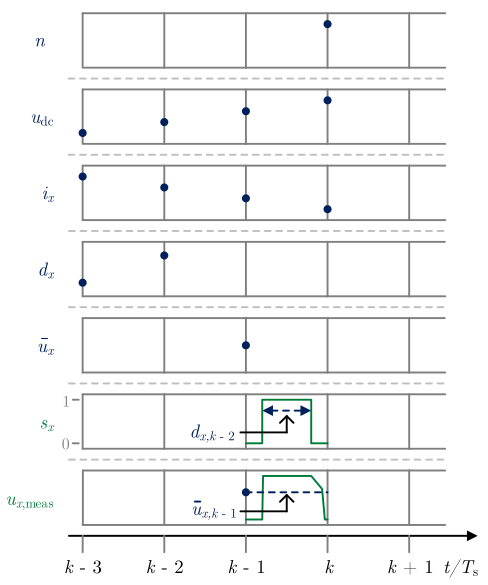
    <figcaption style="margin-top: 10px;">
        <b>Figura 2:</b> Estrutura temporal dos dados (Retirado de STENDER et al., 2020).
    </figcaption>
</figure>
    </td>
  </tr>
</table>

In [7]:
df.describe()

,n_k,u_dc_k,u_dc_k-1,u_dc_k-2,u_dc_k-3,i_a_k,i_b_k,i_c_k,i_a_k-1,i_b_k-1,...,i_c_k-3,d_a_k-2,d_b_k-2,d_c_k-2,d_a_k-3,d_b_k-3,d_c_k-3,u_a_k-1,u_b_k-1,u_c_k-1
count,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,...,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000,234527.000000
mean,1728.414990,567.136398,567.136565,567.136718,567.136882,0.000505,-0.007692,-0.008975,0.000518,-0.007737,...,-0.008874,0.500270,0.500259,0.500157,0.500273,0.500260,0.500156,283.412445,283.467753,283.745740
std,1084.463934,4.993615,4.993462,4.993317,4.993180,2.199349,2.155399,2.216263,2.199206,2.155302,...,2.216061,0.211920,0.211744,0.211753,0.211916,0.211742,0.211751,114.648325,114.290928,114.606340
min,404.433935,548.012908,548.012908,548.012908,548.012908,-7.300153,-6.320221,-7.112914,-7.300153,-6.320221,...,-7.112914,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.288485,-2.087925,-2.312405
25%,507.572918,566.730100,566.730100,566.730100,566.730100,-1.573353,-1.576386,-1.591675,-1.572894,-1.576386,...,-1.591675,0.390344,0.390623,0.390473,0.390354,0.390629,0.390468,231.879423,232.372159,232.330279
50%,1501.516456,568.649812,568.649812,568.649812,568.649812,0.023062,0.000881,0.010400,0.023062,0.000881,...,0.011325,0.500735,0.499997,0.499667,0.500745,0.499975,0.499680,284.749840,284.334880,284.442640
75%,2996.851500,570.126514,570.126514,570.126514,570.126514,1.552902,1.557785,1.566225,1.552902,1.557785,...,1.566225,0.610013,0.609538,0.609828,0.610026,0.609540,0.609827,337.448361,337.198841,338.029761
max,3231.756077,575.553392,575.553392,575.553392,575.553392,7.470243,6.668168,7.437108,7.470243,6.668168,...,7.437108,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,573.338724,573.202404,573.172324


### <a id = "prob"></a> Análise Inicial do Problema 

A modelagem analítica tradicional de inversores de dois níveis enfrenta obstáculos significativos para aplicações de controle em tempo real:

* **Efeitos Não Lineares Complexos:** Fenômenos como o tempo de intertravamento , componentes parasitas e o grampeamento de corrente zero distorcem a tensão de saída

* **Inviabilidade Computacional:** Simular esses efeitos com precisão exigiria passos de tempo na escala de nanossegundos

* **Incerteza de Parâmetros:** Existem variações de fabricação entre as fases e dados insuficientes em manuais técnicos para uma parametrização exata

Para quantificar essas não linearidades, utilizamos o modelo de um **Inversor Ideal** como linha de base. Este modelo ignora quedas de tensão e tempos de comutação, definindo a tensão média de fase ($\overline{u}$) como:

$$\overline{u}_{,x,k-1} = d_{x,k-2} \cdot u_{dc,k-2}$$

**Onde:**
$d_{x,k-2}$: Ciclo de trabalho (*duty cycle*) aplicado

$u_{dc,k-2}$: Tensão medida no barramento CC.

>O **erro de simplificação** plotado a seguir representa a diferença entre a tensão real medida pelos sensores e este valor ideal.

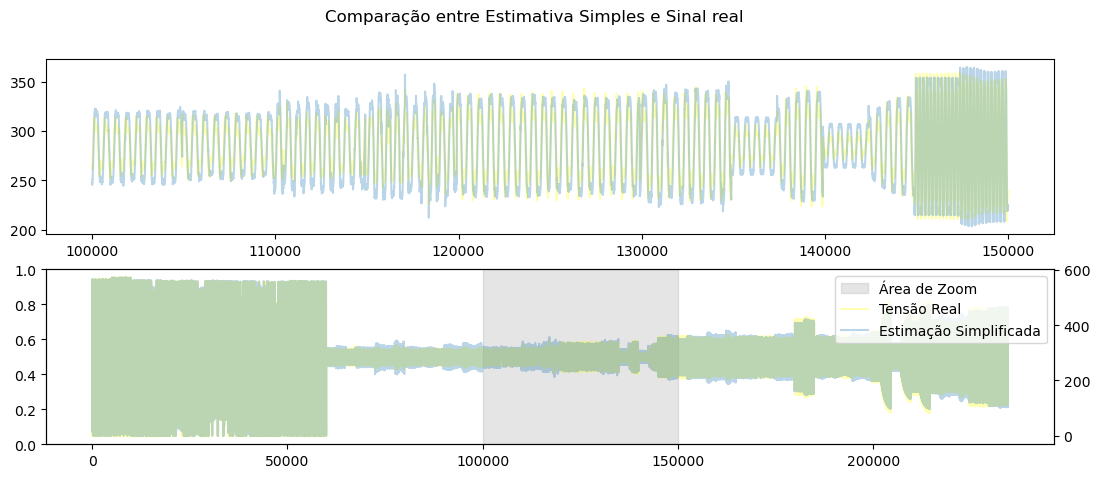

In [8]:
fig, ax = plt.subplots(2,1, figsize = (13,5))
a = 100000
b = 150000

plt.suptitle("Comparação entre Estimativa Simples e Sinal real")
ax[0].plot(df[a:b]['u_a_k-1'], alpha = 0.3, color = "yellow",label = "Tensão Real")
ax[0].plot((df[a:b]['d_a_k-2']*df[a:b]['u_dc_k-2']), alpha = 0.3, label = "Estimação Simplificada")
ax1 = plt.twinx()
ax1.axvspan(a, b, color='gray', alpha=0.2, label="Área de Zoom")
ax1 = plt.plot(df['u_a_k-1'], alpha = 0.3, color = "yellow", label = "Tensão Real")
ax1 = plt.plot((df['d_a_k-2']*df['u_dc_k-2']), alpha = 0.3, label = "Estimação Simplificada")
ax1 = plt.legend(loc = "upper right", fontsize = 10)

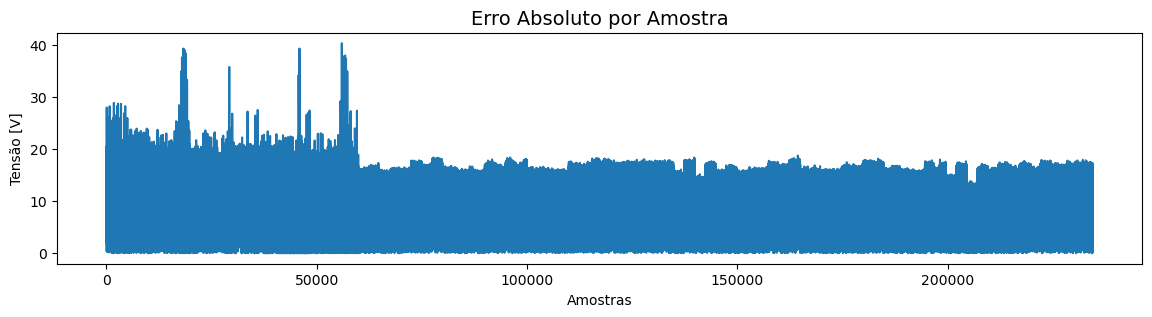

In [9]:
plt.figure(figsize = (14,3))
plt.plot(np.abs((df['u_a_k-1'])-(df['d_a_k-2']*df['u_dc_k-2'])))
plt.title("Erro Absoluto por Amostra", fontsize = 14)
plt.ylabel("Tensão [V]")
plt.xlabel("Amostras")

plt.show()

In [10]:
f = 10e3
T_sample = 1/f

## Estatística Descritiva

### <a id = "ana_ini"></a> Análise e Interpretação Inicial (<a style = "color:blue">Cleyton)

Inicialmente plotamos os dados referentes a velocidade para observar o comportamento dinâmico do motor.

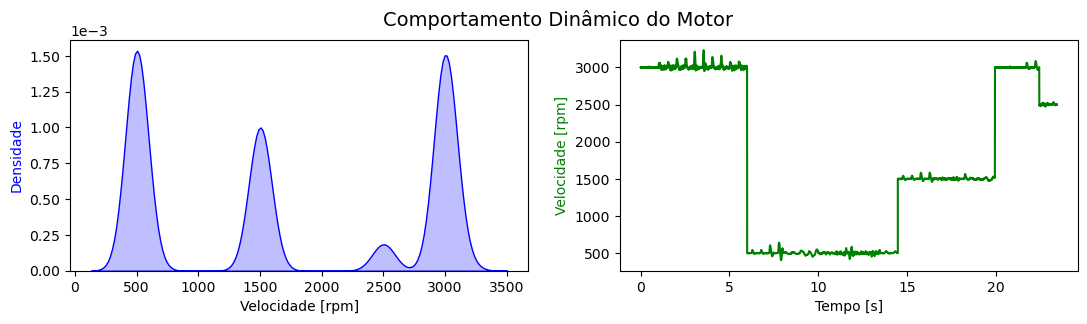

In [11]:

fig, ax = plt.subplots(1,2, figsize=(13,3))

fig.suptitle("Comportamento Dinâmico do Motor", fontsize = title_s)

sns.kdeplot(df.n_k, fill=True, color="blue", ax=ax[0])
ax[0].set_xlabel("Velocidade [rpm]")
ax[0].set_ylabel("Densidade", color = "blue")
ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


ax[1].plot(np.arange(0,len(df.n_k)*T_sample, T_sample),df.n_k, color ="green")
ax[1].set_xlabel("Tempo [s]")
ax[1].set_ylabel("Velocidade [rpm]", color = "green")

plt.show()

#### <a style = "color:green">Thales</a>
>Identificamos três faixas principais de amostragem, que concentra grande parte dos dados de velocidade. Elas são centradas em **500, 1500 e 3000** rpm; esses valores correspondem a velocidade de uso típico do motor. Na frequência nominal de 100 Hz, o motor gira a 3000 rpm, quando ligado a frequência de 50Hz sua velocidade é 1500. A velocidade de 500 rpm também foi privilegiada na quantidade de amostras devido ao torque em baixa velocidade ser crítico para partidas e manobras. Ademais, o conjunto de dados visa contemplar toda a faixa de operação do motor.

#### <a style = "color:blue">Cleyton</a>
>Ao analisar os gráficos acima é possível notar as **quebras temporais na aquisição**. O gráfico exibi patamares de velocidade, o que indica **sessões desconexas e independentes temporalmente** devido aos saltos instantâneos de velocidade não se relacionarem ao comportamento físico real de um motor, devido a propriedade de inércia.

>**<span style = "color:red">Hipótese:</span>** Há sessões de aquisição independentes.

<a id="fft" style="color: black;"></a>

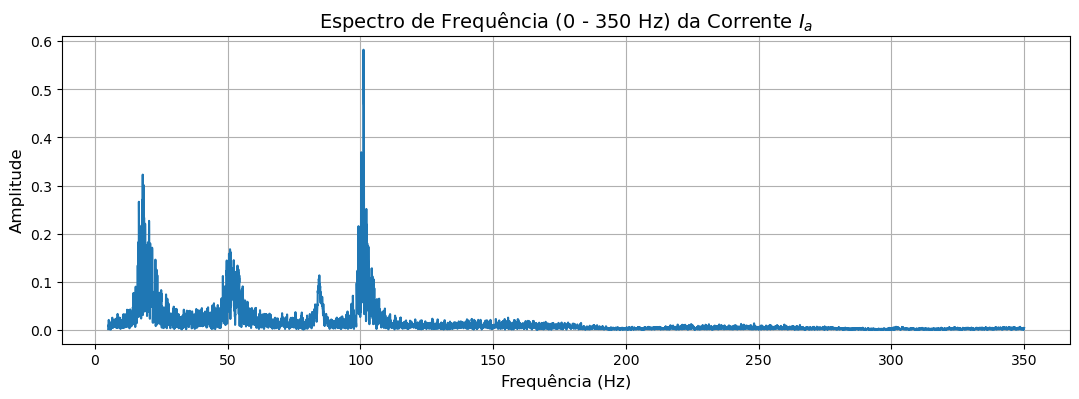

In [12]:
fft_resultado = np.fft.fft(df["i_a_k"])
frequencias = np.fft.fftfreq(len(df["i_a_k-1"]), 1/f)

f_fft=350

n = len(df["i_a_k"])
indices_filtrados = np.where((frequencias >= 5) & (frequencias <= f_fft))

frequencias_plot = frequencias[indices_filtrados]
magnitude = np.abs(fft_resultado)[indices_filtrados] * 2 / n
plot_config(f"Espectro de Frequência (0 - {f_fft} Hz) da Corrente $I_a$","Frequência (Hz)","Amplitude")
plt.plot(frequencias_plot, magnitude)
plt.grid(True)
plt.show()

Como os dados são amostrados em **10 kHz** e as frequências que compõe a corrente cobrem uma faixa bem menor que a de amostragem, o método dos mínimos quadrados ordiários pode ser empregado para observar a dispersão dos dados e se há uma **ordem temporal** entre as amostras.

$$y_i = \beta_0 + \beta_1 x_{i1} + \epsilon_i$$
$$d_{a(k-2)} = \beta_0 + \beta_1 d_{a(k-3)} + \epsilon_i$$


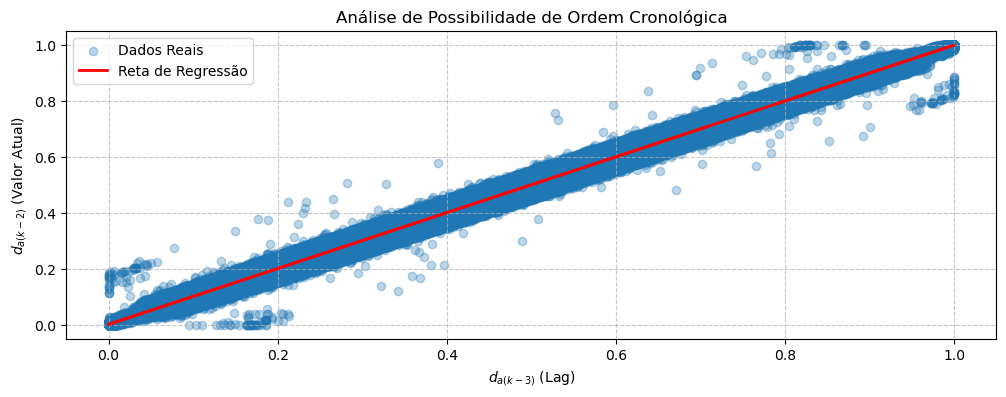

In [21]:
X = np.array(df['d_a_k-3'])
y = np.array(df['d_a_k-2'])

X_com_constante = sm.add_constant(X)
modelo = sm.OLS(y, X_com_constante).fit()

plt.figure(figsize=(12, 4))

plt.scatter(X, y, alpha=0.3, label='Dados Reais')

plt.plot(X, modelo.predict(X_com_constante), color='red', linewidth=2, label='Reta de Regressão')
plt.xlabel('$d_{a(k-3)}$ (Lag)')
plt.ylabel('$d_{a(k-2)}$ (Valor Atual)')

plt.title('Análise de Possibilidade de Ordem Cronológica')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### <a style = "color:blue">Cleyton</a>

>No gráfico acima, os dados estão agrupados próximos a reta, ou seja, a variação dos dados é baixa de uma amostra para outra, **indicando uma possível ordem**.

>É possível notar mais uma informação importante, o agrupamento dos dados pode representar uma superamostragem, podendo gerar vetores Linearmente Dependentes em uma mesma matriz.

>Há um problema em tratar matrizes em que o posto é menor que sua dimensão pois ele define a dimensionalidade das soluções, se o posto for menor que o número de variáveis, o sistema terá infinitas soluções ou nenhuma, pois a "falta" de independência linear resulta em um sistema subdeterminado ou inconsistente.


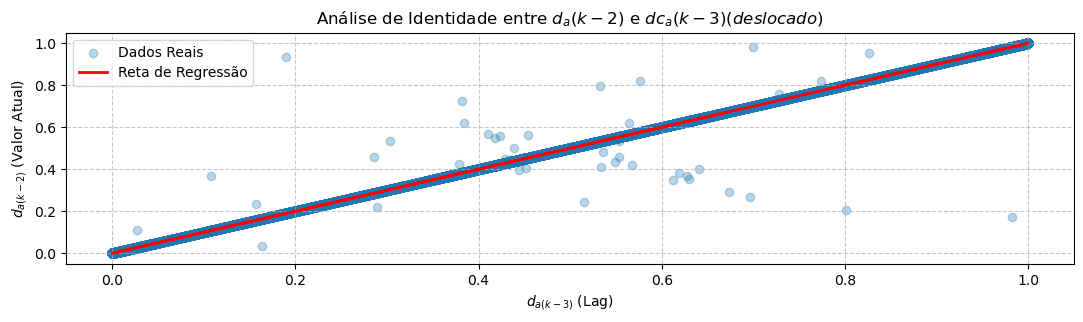

In [14]:
X = np.array(df['d_a_k-3'][1:])
y = np.array(df['d_a_k-2'][:-1])

X_com_constante = sm.add_constant(X)
modelo = sm.OLS(y, X_com_constante).fit()

plt.figure(figsize=(13, 3))

plt.scatter(X, y, alpha=0.3, label='Dados Reais')

plt.plot(X, modelo.predict(X_com_constante), color='red', linewidth=2, label='Reta de Regressão')

plt.xlabel('$d_{a(k-3)}$ (Lag)')
plt.ylabel('$d_{a(k-2)}$ (Valor Atual)')
plt.title(f'Análise de Identidade entre $d_{'a(k-2)'}$ e $dc_{'a(k-3) (deslocado)'}$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### <a style = "color:blue">Cleyton</a>
>Utilizando o mesmo método anterior mas deslocando o vetor $i_{a(k-1)}$ obtemos a identidade (exceto em pontos específicos), **reforçando a <span style = "color:red">[hipótese](#hip)</span>**.

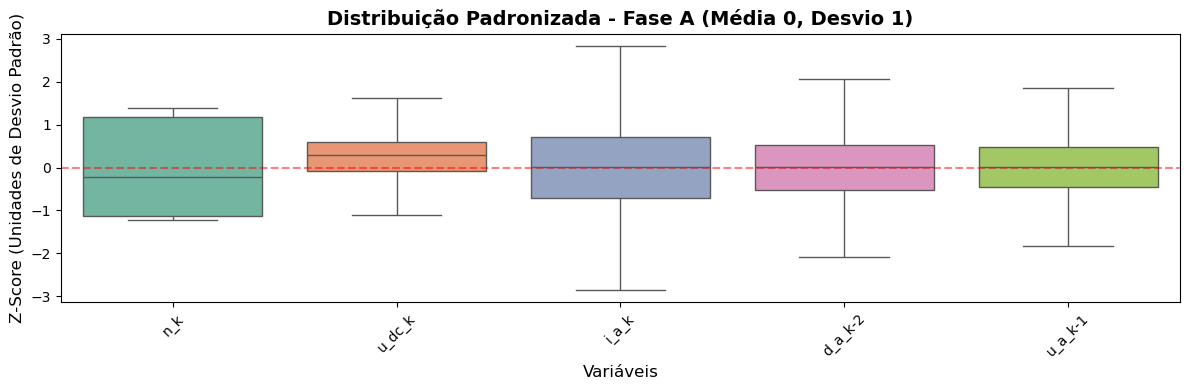

In [15]:
# 1. Definimos as colunas de interesse
fase_a = ['n_k', 'u_dc_k', 'i_a_k', 'd_a_k-2', 'u_a_k-1']

# 2. Filtramos o DataFrame original apenas com essas colunas
# É importante filtrar antes para que o Scaler calcule a média/desvio apenas delas
df_fase_a = df[fase_a]

# 3. Aplicamos a padronização
scaler = StandardScaler()
# O fit_transform retorna um array NumPy, então transformamos de volta em DataFrame
df_scaled = pd.DataFrame(scaler.fit_transform(df_fase_a), columns=fase_a)

# 4. Plotamos o gráfico
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_scaled, showfliers=False, palette="Set2")

plt.title('Distribuição Padronizada - Fase A (Média 0, Desvio 1)', fontsize=14, fontweight='bold')
plt.ylabel('Z-Score (Unidades de Desvio Padrão)', fontsize=12)
plt.xlabel('Variáveis', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Linha de referência no zero
plt.tight_layout()

plt.show()

### <a id = "comp_dad"></a>Comprovação com os dados fornecidos

#### <a style = "color:green">Thales</a>
Além disso ao plotarmos a **<a href="#fft">FFT</a>**  do sinal de corrente que entra no MIT mostramos que a frequência principal é de 100 Hz. Esse valor é calculado a partir dos dados nominais do motor (<a href = "#esp_mot" >Figura 3</a>). Para um MIT, a velocidade síncrona é dada por $$ n = \frac{120 \cdot f}{P} $$

>Substituindo os valores nominais, obtemos a frequência de operação nominal de 100 Hz .

<a id = "esp_mot" ></a>
<figure id="malha_controle" style="text-align: center;">
    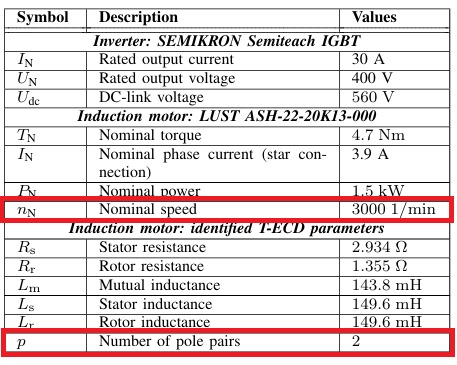
    <figcaption>
        <b>Figura 3:</b> Características do Inversor e do Motor de Indução (Retirado de STENDER et al., 2020).
    </figcaption>
</figure>

>**Conclusão**: Podemos ver  alta concentracao de dados para a tensão de barramento $u_{dc(k)}$. MUDAR

#### <a style = "color:green">Thales</a>
Queremos mostrar através da probabilidade e do cálculo da Esperança a concentração dos dados de Duty cycle em torno de 0.5. Como mostrado na <a href="#duty_dis">Figura 4</a>

<a id="duty_dis"></a>
<figure id="dispersao_duty" style="text-align: center;">
    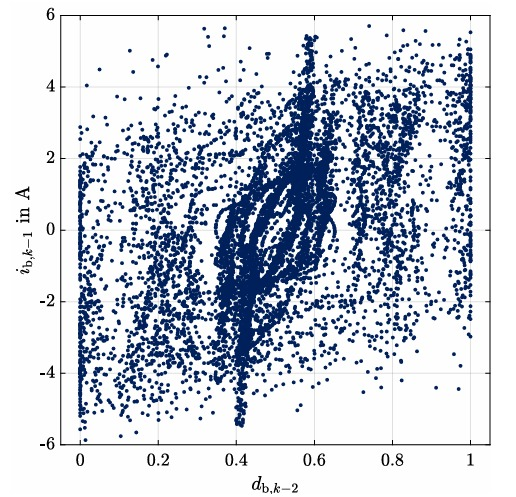
    <figcaption>
        <b>Figura 4:</b> Ciclo de trabalho $d_{b,k-2}$ e valor da corrente de fase $i_{b,k-1}$ para 10.000 amostras do conjunto de dados selecionadas aleatoriamente.  (Retirado de STENDER et al., 2020).
    </figcaption>
</figure>
  


In [16]:
prob_faixa = ((df['d_b_k-2'] >= 0.35) & (df['d_b_k-2'] <= 0.66)).mean() 
print(f"Probabilidade da amostra estar dentro do intervalo especificado abaixo")
print(f"P({0.35} ≤ X ≤ {0.66}) = {prob_faixa:.3f}")

esperanca = (df["d_b_k-2"]).mean()
print(f'\nEsperança de d_b(k-2) = {esperanca:.3f}')

Probabilidade da amostra estar dentro do intervalo especificado abaixo
P(0.35 ≤ X ≤ 0.66) = 0.662

Esperança de d_b(k-2) = 0.500


#### <a style = "color:green">Thales</a>
>**Conclusão** Podemos verificar numericamente que o duty cycle está mais concentrado dentro de uma faixa (0.4 e 0.6) específica, conforme observado nos resultados acima. O intervalo interquartil ($Q_3-Q_1$) do boxplot também confirma essa alta concentração de dados nessa faixa.

### <a id = "idi_ses"></a>Identificando e Separando Sessões

#### <a style = "color:blue">Cleyton</a>
>#### Para identificar as diferentes sessões o código abaixo utiliza o método descrito em [Fórmula I: Lógica temporal](#logica_sessao)


In [82]:
index = (np.where(df["i_a_k"].values != np.append(df["i_a_k-1"].values, [0])[1:]))[0]+1
print("Índice de amostra que identifica sessões diferentes:", index)
print(f"No total, temos {(len(index))} sessões")

Índice de amostra que identifica sessões diferentes: [  4996   9992  14988  19984  24980  29976  34972  39968  44964  49960
  54956  59952  64948  69944  74940  79936  84932  89928  94924  99920
 104916 109912 114908 119904 124900 129896 134892 139888 144884 149880
 154876 159872 164868 169864 174860 179856 184852 185989 189563 194559
 199555 204551 209547 214543 219539 224535 229531 234527]
No total, temos 48 sessões


>A lógica empregada indentificou <strong>48 interrupções</strong>. Esse teste foi realizado em todas as variáveis que contém o histórico e comparado com os saltos em velocidade. 

In [53]:
index2 = (np.where(df["i_a_k"].values == np.append(df["i_a_k"].values, [0])[1:]))[0]+1
print("Índice de amostra que identifica sessões diferentes:", index2)
print(f"No total, temos {(len(index2))} sessões repetidas")

Índice de amostra que identifica sessões diferentes: [  1213   1643   1900 ... 233887 234417 234419]
No total, temos 1702 sessões repetidas


>Foram também identificados leituras repetidas

In [55]:
pontos = np.append(0,index)
sessoes = [df.iloc[pontos[i]:pontos[i+1]] for i in range(len(pontos)-1)]

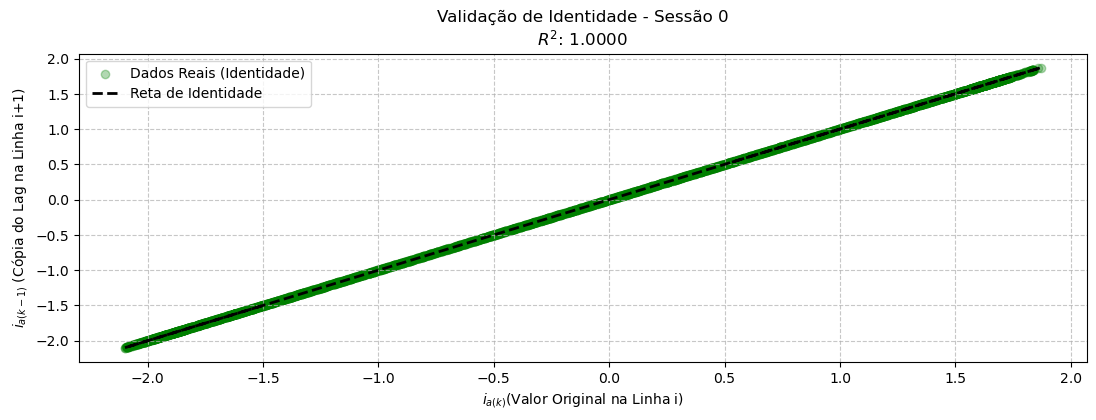

In [36]:
sessao_alvo = sessoes[20]

X = np.array(sessao_alvo['i_a_k'][:-1])            
y = np.array(sessao_alvo['i_a_k-1'][1:].values) 

X_com_constante = sm.add_constant(X)
modelo = sm.OLS(y, X_com_constante).fit()

plt.figure(figsize=(13, 4))

plt.scatter(X, y, alpha=0.3, color='green', label='Dados Reais (Identidade)')

plt.plot(X, modelo.predict(X_com_constante), color='black', linestyle='--', linewidth=2, label='Reta de Identidade')

plt.xlabel('$i_{a(k)} $(Valor Original na Linha i)')
plt.ylabel('$i_{a(k-1)}$ (Cópia do Lag na Linha i+1)')
plt.title(f'Validação de Identidade - Sessão 0\n$R^2$: {modelo.rsquared:.4f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### <a id = "corr"></a>Correlação entre as Variáveis

#### <a id = 'corr_alt'></a>Análise de dois sinais com correlação de Pearson alta

#### <a style = "color:green">Thales</a>

Vamos olhar os principais sinais do sistema: o duty cycle e a tensão associada que está sob efeito desse duty cycle. Esperamos uma alta correlação entre o duty cycle $d_{x(k-2)}$ e a tensão de fase $u_{x(k-1)}$ (que é a que recebe essa influência), conforme o dataset sugere na <a href ="#dut_u">Figura 5</a>. O efeito de $d_{x(k-2)}$ influencia $u_{x(k-1)}$ devido ao atraso (delay) do duty cycle.

<a id = "dut_u"></a>
<figure id="dadas" style="text-align: center;">
    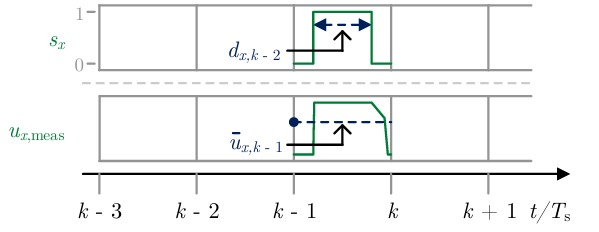
    <figcaption>
        <b>Figura 5:</b> Adaptada da figura 5 do artigo (Adaptado de STENDER et al., 2020).
    </figcaption>
</figure>

O duty cycle $d_{x(k-2)}$ atua como entrada do inversor, influenciando diretamente as tensões de saída das três fases $u_{{a,b,c}(k-1)}$. 

<a id = "alt_cor"></a>.
<figure id="dadas" style="text-align: center;">
    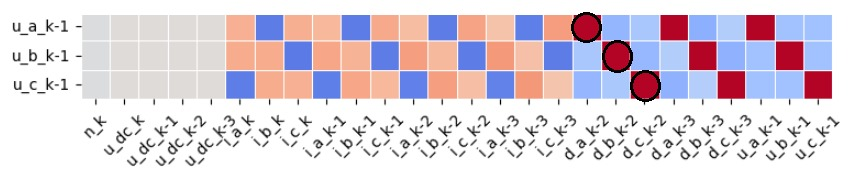
    <figcaption>
        <b>Figura 6:</b> Destaque da matriz de correlação (cool‑warm) evidenciando o par $(d_{x(k-2)},u_{x(k-1)})$.
    </figcaption>
</figure>

>A alta correlação linear observada (vermelho no mapa de calor) **reflete** essa relação **causal** para todas as fases, conforme destacado na <a href = "#alt_cor">Figura 6</a>.

#### Relação Linear entre Tensão de fase e Duty cycle

Em azul, plotamos os pontos do dataset (Tensão de Fase) $u_{a(k-1)}$ x $d_{a(k-2)}$ (Duty Cicle). Em vermelho, sobrepomos a reta de regressão calculada pelo método dos mínimos quadrados (`np.polyfit`), cujos coeficientes angular e linear são exibidos.

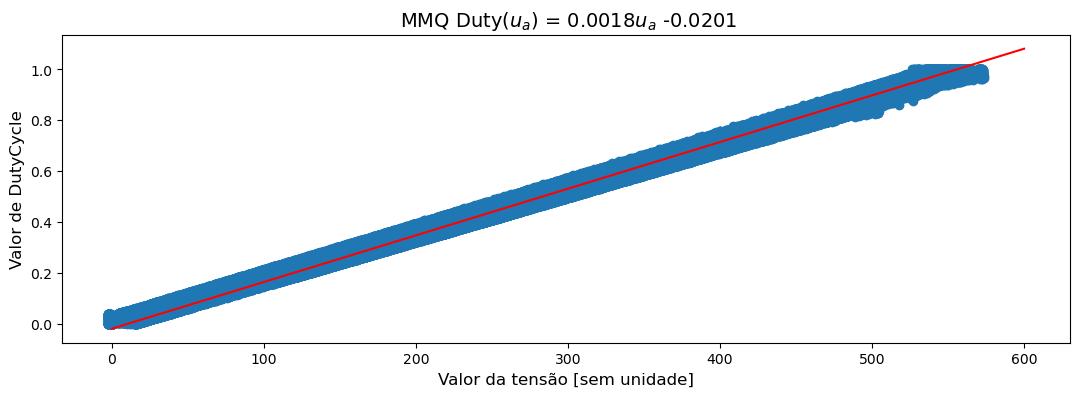

In [37]:
Ua= df["u_a_k-1"]
Duty= df["d_a_k-2"]

plt.figure(figsize = (13,4))

plt.scatter (Ua,Duty)  

coeficiente_reta_regress = np.polyfit(Ua,Duty,1) # esse último 1 significa que é do primeiro grau (MMQ método dos mínimos quadrados)
coef_angular = coeficiente_reta_regress [0]
coef_linear = coeficiente_reta_regress [1]

plt.title(f" MMQ Duty($u_a$) = {coef_angular:.4f}$u_a$ {coef_linear:.4f}", fontsize = 14)

### plotar reta de regressão 
eixoX = np.linspace(0, 600, 100)
eixoY= coef_angular * eixoX + coef_linear

#plt.figure(2) 
plt.plot (eixoX, eixoY, color="red")
plt.ylabel("Valor de DutyCycle", fontsize=12)   
plt.xlabel("Valor da tensão [sem unidade]", fontsize=12)

plt.show()


#### <a style = "color:green">Thales</a>
>**Conclusão** : a correlação alta pode ser verificada pelo valor do coeficiente de Pearson. Como ele é elevado, isso significa que o conjunto de dados pode ser bem descrito por uma reta de regressão. Utiliza-se a função `np.polyfit`, que implementa o método dos mínimos quadrados (MMQ) para esse fim. Abaixo, mostramos o conjunto de dados em azul e a reta de regressão em vermelho. Esta análise é monofásica, mas, conforme discutido anteriormente, pode ser estendida às três fases.


In [38]:
print(f"Valor do coeficiente de correlação entre as variáveis Ua e Duty Cycle :")
print(round(np.corrcoef(Ua,Duty)[0,1],3)) ## Mostrar o grau de correlação

Valor do coeficiente de correlação entre as variáveis Ua e Duty Cycle :
0.993


### Análise das Formas de Ondas das Correntes Trifásicas


#### <a style = "color:green">Thales</a>
#### Dedução: Correlação de Pearson entre Senoides Defasadas em 120°

O coeficiente de correlação de Pearson é definido pela razão entre a covariância e o produto dos desvios padrão:

$$\rho_{X,Y} = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}$$

#### 1. Definição das Variáveis
Consideramos duas senoides puras com média zero:
* $X(t) = A\sin(\omega t)$
* $Y(t) = A\sin(\omega t + \phi)$, onde $\phi = 120^\circ$ (ou $\frac{2\pi}{3}$ rad)

#### 2. Numerador: Covariância
Como as médias são nulas, a covariância simplifica para o valor esperado do produto $E[XY]$:

$$\text{cov}(X, Y) = \frac{1}{T} \int_{0}^{T} A^2 \sin(\omega t) \sin(\omega t + \phi) dt$$

Aplicando a identidade trigonométrica do produto de senos e integrando:
$$\text{cov}(X, Y) = \frac{A^2}{2} \cos(\phi)$$

#### 3. Denominador: Padronização ($\sigma_X \sigma_Y$)
A variância de uma senoide pura de amplitude $A$ é $\frac{A^2}{2}$, logo o desvio padrão ($\sigma$) é o seu valor RMS:

$$\sigma_X = \sigma_Y = \frac{A}{\sqrt{2}} \implies \sigma_X \sigma_Y = \frac{A^2}{2}$$

#### 4. Conclusão
Substituindo os termos na fórmula de Pearson:

$$\rho_{X,Y} = \frac{\frac{A^2}{2} \cos(\phi)}{\frac{A^2}{2}} = \cos(\phi)$$

Para uma defasagem de **120°**:
$$\rho = \cos(120^\circ) = -0,5$$

As correlações podem ser utilizadas de forma indireta, neste caso, como evidência do comportamento senoidal das correntes que entram no MIT. Por serem aproximadamente senoidais e defasadas 120° entre si, elas têm a propriedade de apresentar um coeficiente de correlação linear igual a **-0,5** (cos 120°).

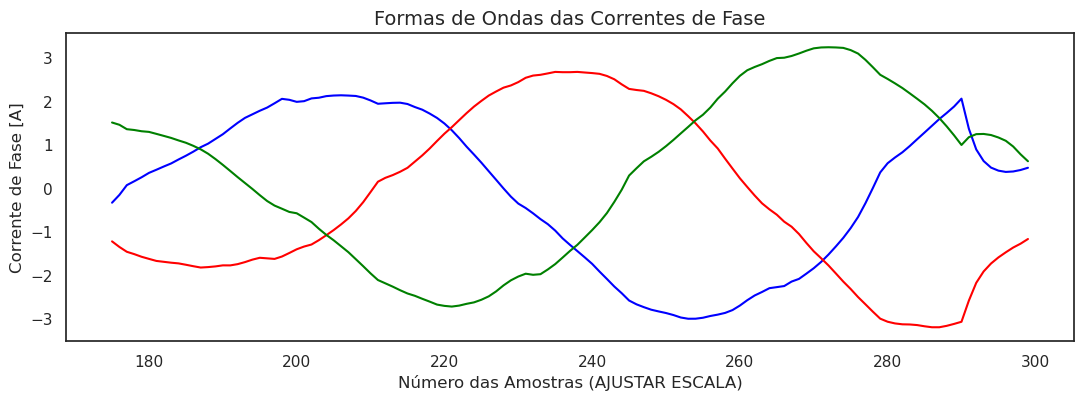

Segue abaixo o valor da correlação calculado:
Entre as correntes da fase A e B temos: 
-0.482
Entre as correntes da fase B e C temos: 
-0.493
Entre as correntes da fase A e B temos: 
-0.524


In [84]:
plot_config("Formas de Ondas das Correntes de Fase", "Número das Amostras (AJUSTAR ESCALA)", "Corrente de Fase [A]")
plt.plot(df["i_a_k-1"][175:300], color = "blue")
plt.plot(df["i_b_k-1"][175:300], color = "red")
plt.plot(df["i_c_k-1"][175:300], color = "green")
plt.show()
print(f"Segue abaixo o valor da correlação calculado:")
print (f"Entre as correntes da fase A e B temos: ")
print(round(np.corrcoef(df["i_a_k"],df["i_b_k"])[0,1],3)) ## Mostrar o grau de correlação
print (f"Entre as correntes da fase B e C temos: ")
print(round(np.corrcoef(df["i_b_k"],df["i_c_k"])[0,1],3)) 
print (f"Entre as correntes da fase A e B temos: ")
print(round(np.corrcoef(df["i_a_k"],df["i_c_k"])[0,1],3))

#### <a style = "color:green">Thales</a>
>**Conclusão**: Conforme podemos observar essa relação é aproximadamente preservada em todas as fases para um mesmo intervalo e próximos de -0.5. 

### Verificação do Módulo das Correntes de Fase

In [64]:
desvio = st.stdev(df["u_dc_k"])
desvio2 = st.stdev(df["i_a_k-1"])
desvio3 = st.stdev(df["i_b_k-1"])                   
desvio4 = st.stdev(df["i_c_k-1"])
desvio5 = st.stdev(df["u_a_k-1"])
desvio6 = st.stdev(df["u_b_k-1"])
desvio7 = st.stdev(df["u_c_k-1"])
print(f'Desvio da tensão do link dc = {desvio}')

print(f'\nDesvio das Correntes de Fase')
print(f'Fase A: {desvio2:.4f}, Fase B: {desvio3:.4f} e Fase C: {desvio4:.4f}')

print(f'\nDesvio das Tensões de Fase')
print(f'Fase A: {desvio5:.4f}, Fase B: {desvio6:.4f} e Fase C: {desvio7:.4f}')

Desvio da tensão do link dc = 4.993614529498334

Desvio das Correntes de Fase
Fase A: 2.1992, Fase B: 2.1553 e Fase C: 2.2162

Desvio das Tensões de Fase
Fase A: 114.6483, Fase B: 114.2909 e Fase C: 114.6063


#### <a style = "color:green">Thales</a>
>**Conclusão** Inicialmente levantamos uma inicial de que as correntes e tensões de fase são equilibradas, devido as variações entre as fases serem muito 
próxima, podemos constatar que estão equilibradas em módulo.


### <a id = "paradox"></a>Análise das Matrizes de Correlação e o Paradoxo de Simpson

#### <a style = "color:blue">Cleyton</a>

Nesta seção analisaremos a **relação entre as variáveis** do dataset, focando principalmente em mostrar a correlação linear entre elas e a varíavel alvo $u_{x(k-1)}$. 

Como identificado anteriomente, há diferentes sessões de aquisição e inicialmente avaliaremos se a correlação se mantem entre a aquisição geral e as sessões individuais.

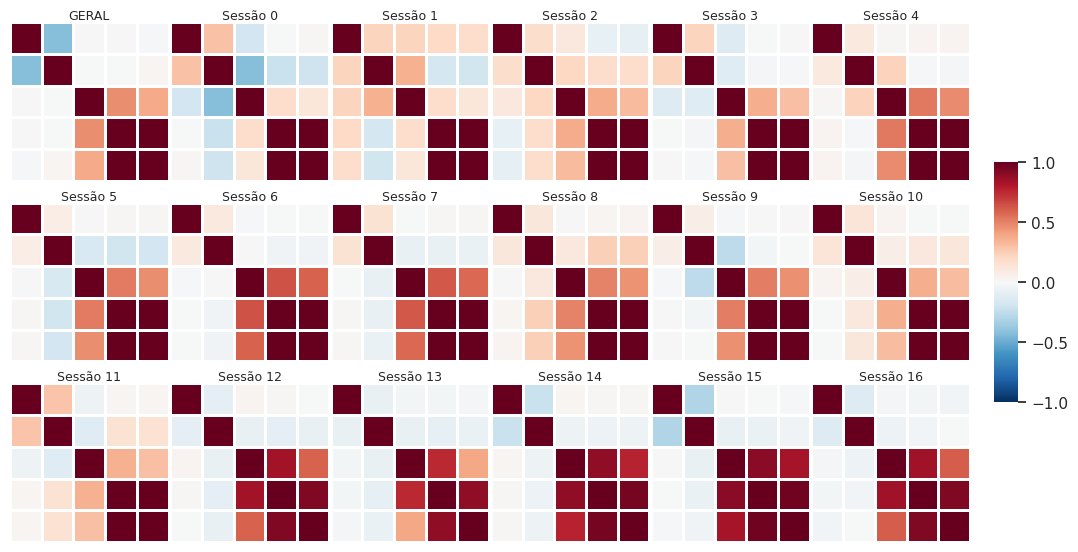

In [79]:
sns.set_theme(style="white")
n_rows, n_cols = 3, 6
fase_a = ['n_k', 'u_dc_k', 'i_a_k', 'd_a_k-2', 'u_a_k-1']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6))
axes = axes.flatten()

# Calculando a matriz geral primeiro para referência
corr_geral = df[fase_a].corr()

for i in range(18):
    ax = axes[i]
    
    if i == 0:
        
        corr_matrix = corr_geral
        titulo = "GERAL"
        cmap = "RdBu_r" 
        linewidths = 1
        cbar_ax = fig.add_axes([.92, .3, .02, .4]) 
        
    else:
        
        indice_sessao = i - 1
        corr_matrix = sessoes[indice_sessao][fase_a].corr()
        titulo = f"Sessão {indice_sessao}"
        cmap = "RdBu_r"
        linewidths = 1
    
    sns.heatmap(corr_matrix, 
                annot=False,          # Sem números (poluem a visão de padrão)
                cmap=cmap, 
                vmin=-1, vmax=1,      # ESCALA FIXA É CRUCIAL
                center=0,
                square=True, 
                cbar=(i == 0),        # Barra de cor apenas no primeiro ou externa
                cbar_ax=cbar_ax if i == 0 else None,
                xticklabels=False,    # Remove labels para limpar o visual
                yticklabels=False, 
                linewidths=linewidths,
                ax=ax)
    
    ax.set_title(titulo, fontsize=9, pad=2)

# Ajuste fino de espaçamento
plt.subplots_adjust(left=0.1, right=0.9, top=0.95, bottom=0.05, wspace=0.01, hspace=0.01)
plt.show()

#### <a style = "color:blue">Cleyton</a>
>Visualmente podemos observar padrões entre as sessões e uma característica destoante da sessão geral em comparação com as sessões fragmentadas. Essa característica será abordada analiticamente abaixo.


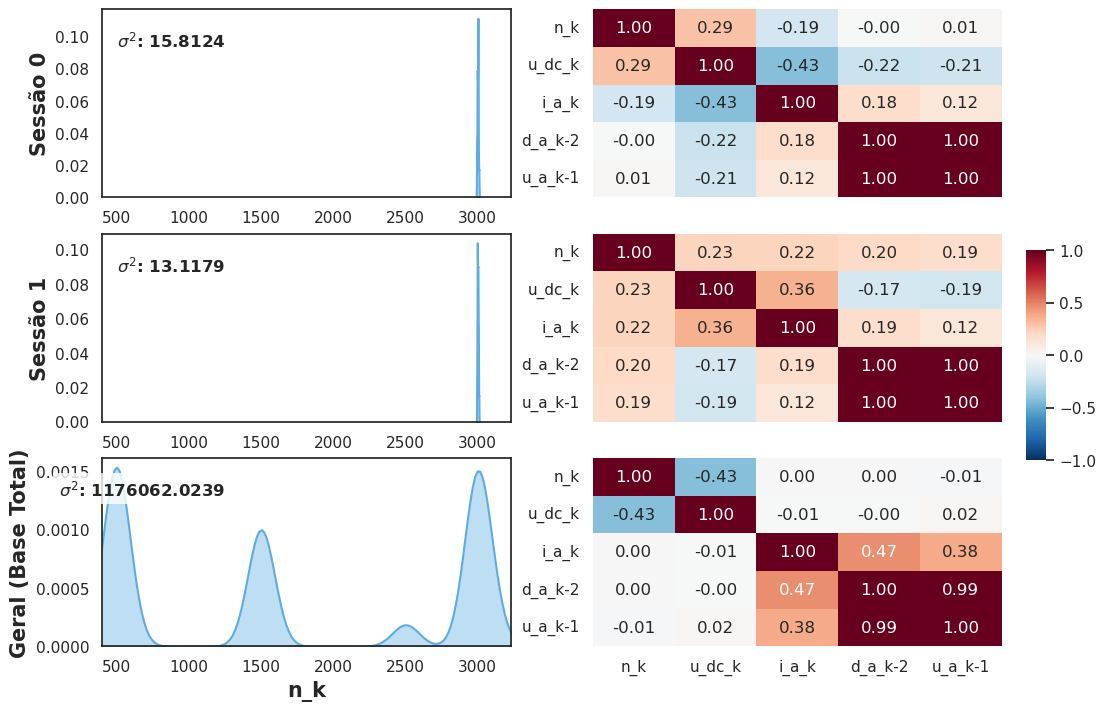

In [86]:
# 1. Defina aqui qual variável deseja analisar na coluna do KDE
var_analise = 'n_k'  # Você pode trocar para 'u_dc_k', 'i_a_k', etc.

fase_a = ['n_k', 'u_dc_k', 'i_a_k', 'd_a_k-2', 'u_a_k-1']

fig, axes = plt.subplots(3, 2, figsize=(10, 7), constrained_layout=True,
                         gridspec_kw={'width_ratios': [1, 1]})

datasets = [sessoes[0], sessoes[1], df]
titulos = ["Sessão 0", "Sessão 1", "Geral (Base Total)"]

# Ajuste automático dos limites do eixo X com base na variável escolhida
x_min, x_max = df[var_analise].min(), df[var_analise].max()

cbar_ax = fig.add_axes([1.02, 0.35, 0.02, 0.3])

for i, (data, titulo) in enumerate(zip(datasets, titulos)):
    
    # ==========================================
    # COLUNA 0: Gráfico de Distribuição (KDE)
    # ==========================================
    ax_kde = axes[i, 0]
    sns.kdeplot(data[var_analise], fill=True, color="#5DADE2", alpha=0.4, linewidth=1.5, ax=ax_kde)
    
    # Cálculo da variância para a variável dinâmica
    var_val = data[var_analise].var()
    ax_kde.text(0.3, 0.8, rf"$\sigma^2$: {var_val:.4f}", transform=ax_kde.transAxes, 
                ha='right', fontsize=12, fontweight='bold', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Ajustes de eixos do KDE
    ax_kde.set_ylabel(titulo, fontsize=15, fontweight='bold')
    ax_kde.set_xlim(x_min, x_max)
    
    # Rótulo dinâmico no eixo X
    if i < 2: 
        ax_kde.set_xlabel("")
    else:
        ax_kde.set_xlabel(var_analise, fontsize=15, fontweight='bold')

    # ==========================================
    # COLUNA 1: Matriz de Correlação (Heatmap)
    # ==========================================
    ax_corr = axes[i, 1]
    corr = data[fase_a].corr()
    
    sns.heatmap(corr, 
                annot=True, fmt=".2f", cmap="RdBu_r", 
                vmin=-1, vmax=1, center=0,
                square=False, 
                ax=ax_corr,
                cbar=(i == 0), 
                cbar_ax=cbar_ax if i == 0 else None,
                xticklabels=fase_a if i == 2 else False, 
                yticklabels=True)
    
    # ax_corr.set_title(f"Padrão de Correlação: {titulo}", fontsize=11, pad=10)

plt.savefig("var.png")
plt.show()

#### <a style = "color:blue">Cleyton</a>
A divergência entre as matrizes de correlação de cada sessão e a matriz agregada caracteriza de forma clara o **Paradoxo de Simpson**. Ao analisar o coeficiente de Pearson através da sua formulação matemática:

<a id="pearson"></a>
$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Percebe-se que o cálculo depende da variância em relação à média global ($\bar{x}, \bar{y}$). Quando agrupamos regimes de operação distintos, os "saltos" nos níveis de estado entre as sessões introduzem uma **dispersão artificial** que mascara a física real do sistema.<span style="color:blue"> **Como observado na Variância dos gráficos acima.**</span>

#### Dinâmica do Sistema vs. Artefatos de Transição

* **Correlação por Sessão (Dinâmica Real):** Reflete a resposta do inversor em regime permanente. Nas Sessões 0 e 1, observa-se uma **correlação negativa** entre $u_{dc(k)}$ e $u_{a(k-1)}$. Isso indica que, dentro de um mesmo regime, as variáveis oscilam de forma síncrona, respeitando as leis de controle e a dinâmica intrínseca do hardware.
* **Correlação Global (Artefato Estatístico):** A agregação dos dados inverte o sinal para uma **correlação negativa**. Isso ocorre porque o coeficiente passa a ser dominado pelo deslocamento das médias (os "saltos") entre os regimes. Esse resultado não descreve o comportamento do inversor, mas sim um artefato gerado pela quebra na aquisição dos dados.

><span style = "color:blue">**Conclusão:**</span> A matriz de correlação global é, portanto, enganosa para a modelagem do sistema. Para capturar a verdadeira sensibilidade entre as variáveis, a análise segmentada é fundamental, tratando as transições entre regimes como descontinuidades externas e não como correlação estatística.

### <a id = "esp"></a> Relações espúrias

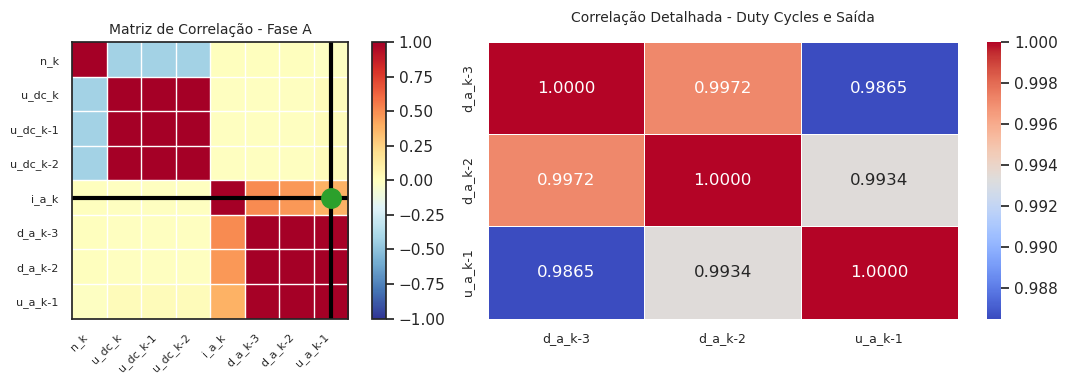

In [83]:
fase_a = ['n_k', 'u_dc_k','u_dc_k-1', 'u_dc_k-2','i_a_k', 'd_a_k-3', 'd_a_k-2', 'u_a_k-1']
subconjunto = ['d_a_k-3', 'd_a_k-2', 'u_a_k-1']

corr_matrix_total = df[fase_a].corr()
corr_matrix_sub = df[subconjunto].corr()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Matriz completa
fig_corr = sm.graphics.plot_corr(corr_matrix_total, 
                                xnames=fase_a, 
                                ynames=fase_a, 
                                title="Matriz de Correlação - Fase A", 
                                normcolor=True, 
                                ax=ax1)

# ==========================================
# ADIÇÃO DAS MARCAÇÕES NA IMAGEM (ax1)
# ==========================================
# i_a_k é o índice 4, u_a_k-1 é o índice 7
eixo_x_alvo = 7.5
eixo_y_alvo = 3.5

# Linhas preenchidas pretas e espessas
ax1.axhline(y=eixo_y_alvo, color='black', linewidth=3)
ax1.axvline(x=eixo_x_alvo, color='black', linewidth=3)

# Ponto verde na interseção
ax1.plot(eixo_x_alvo, eixo_y_alvo, marker='o', color='#2ca02c', markersize=14, zorder=5)
# ==========================================

im1 = ax1.get_images()[0]
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax1.title.set_fontsize(10)
ax1.tick_params(axis='both', which='major', labelsize=8)

# Plot 2: Matriz detalhada (subset)
sns.heatmap(corr_matrix_sub, 
            annot=True, 
            fmt=".4f", 
            cmap="coolwarm", 
            linewidths=0.5, 
            ax=ax2)

ax2.set_title("Correlação Detalhada - Duty Cycles e Saída", fontsize=10, pad=15)
ax2.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

#### <a style = "color:yellow"> Danilo</a>

A análise da primeira matriz de correlação indica a existência de associações entre variáveis em instantes distintos, como no caso da correlação observada entre $i_{ak}$ e $u_{ak-1}$. Esse tipo de relação poderia sugerir um comportamento não causal, em que valores futuros influenciariam o presente, o que não é adequado do ponto de vista físico e estatístico.

Esse padrão pode ser explicado pela autocorrelação presente em sinais temporais de sistemas dinâmicos. Como as variáveis são amostradas em instantes muito próximos, seus valores consecutivos tendem a ser semelhantes, gerando correlações entre defasagens temporais. Além disso, as variáveis em questão (tensão e corrente), em sistemas físicos, apresentam dependência temporal devido à dinâmica do sistema.

>Portanto, a correlação observada não indica causalidade invertida, mas sim um comportamento esperado decorrente da dinâmica do sistema e da proximidade temporal entre as amostras.

>Além disso, o gráfico de correlação apresentado à direita pode ser interpretado como um “zoom” de uma região específica do gráfico à esquerda. Essa ampliação permite uma análise mais detalhada, evidenciando que a correlação de $( d_{ak-2}) $ com a saída $( u_{ak} )$ é mais forte do que a de $( d_{ak-3} )$, o que reforça a relevância dos atrasos mais próximos na dinâmica do sistema.

In [49]:
from scipy.signal import correlate # Importa a função correlate do módulo scipy.signal

ia = df['i_a_k-1'].values # .values faz virar um array do numpy
ib = df['i_b_k-1'].values
ic = df['i_c_k-1'].values

def atraso(s1, s2):  # define uma função chamada atraso que vai receber s1 e s2 
    corr = correlate(s1, s2) # aqui é calculado o array de correlação que é um teste de encaixe para cada  
    # deslocamento possível. O pico do array indica o deslocamento que melhor alinha os dois sinais!
   
    return np.argmax(corr) - len(s1) + 1 #aqui encontra-se o indice máximo de correlação através de np.argmax

atraso_AB = atraso(ia, ib)
atraso_AC = atraso(ia, ic)
atraso_BC = atraso(ib, ic)

print(f"Atrasos:")
print(f"de A para B = {atraso_AB}")
print(f"de A para C = {atraso_AC}") 
print(f"de B para C = {atraso_BC}")

Atrasos:
de A para B = -231
de A para C = 232
de B para C = -232


2999.32618912273


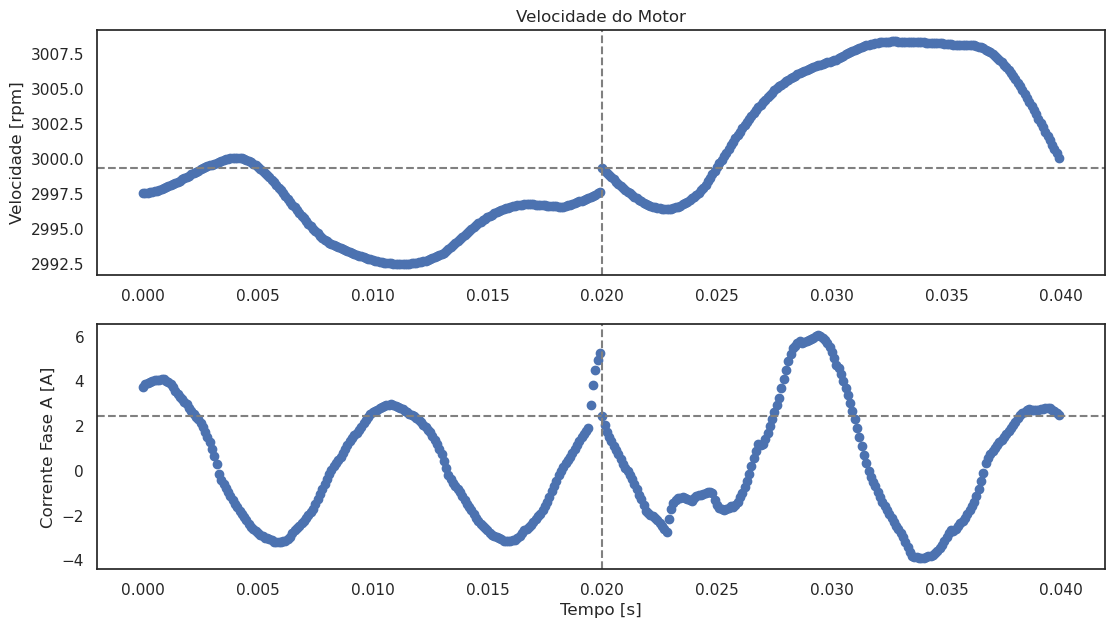

In [45]:
fig, axes = plt.subplots(2,1, figsize=(13,7))
teste = 4996
tamanho = 200

axes[0].scatter(np.arange(0,len(df.n_k[teste-tamanho:teste+tamanho])*T_sample,T_sample),df.n_k.iloc[teste-tamanho:teste+tamanho])
axes[0].set_title("Velocidade do Motor")
# axes[0].set_xlabel("Tempo [s]")
axes[0].set_ylabel("Velocidade [rpm]")
axes[0].axhline(y=df.n_k[teste], xmax=1, color='gray', linestyle='--')
axes[0].axvline(x=(tamanho)*T_sample, ymax=1, color='gray', linestyle='--')

axes[1].scatter(np.arange(0,len(df.n_k.iloc[teste-tamanho:teste+tamanho])*T_sample,T_sample),df["i_a_k-1"].iloc[teste-tamanho:teste+tamanho])
axes[1].set_xlabel("Tempo [s]")
axes[1].set_ylabel("Corrente Fase A [A]")
axes[1].axhline(y=df["i_a_k-1"][teste], xmax=1, color='gray', linestyle='--')
axes[1].axvline(x=(tamanho)*T_sample, ymax=1, color='gray', linestyle='--')

print(df.n_k[teste])

plt.show()